In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/transactions_clean.csv")

print(fund_master.shape)
print(nav_history.shape)
print(transactions.shape)

(40, 15)
(46000, 3)
(32778, 13)


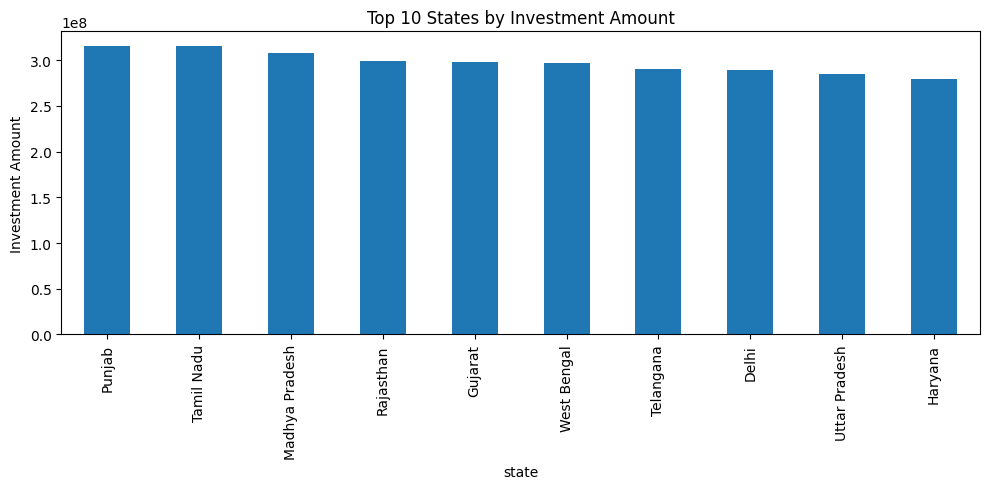

In [5]:
state_investment = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
state_investment.plot(kind="bar")

plt.title("Top 10 States by Investment Amount")
plt.ylabel("Investment Amount")

plt.tight_layout()

plt.savefig("../reports/charts/state_investment.png")

plt.show()

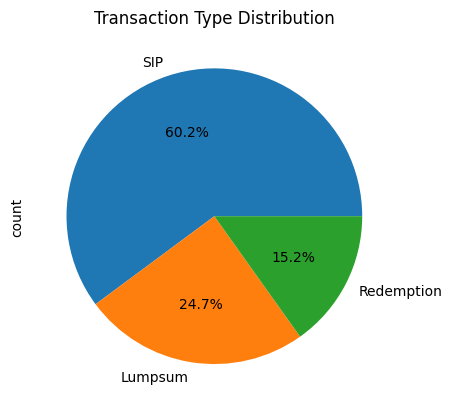

In [4]:
transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")
plt.savefig("../reports/charts/transaction_type_distribution.png")
plt.show()

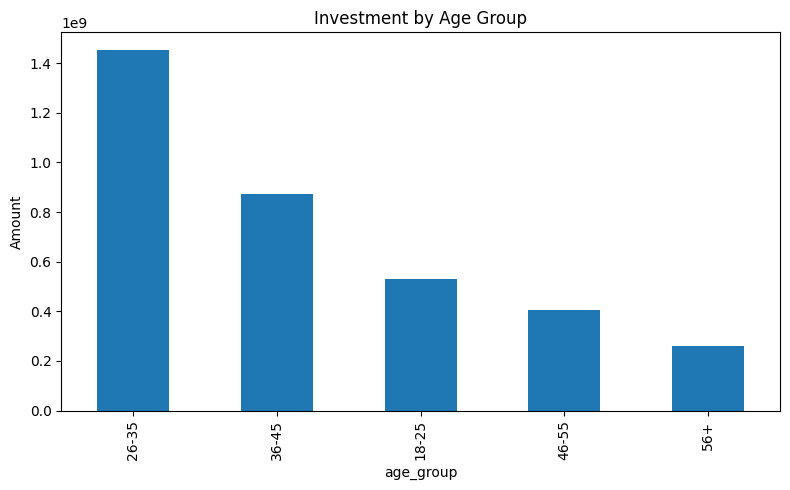

In [6]:
age_analysis = (
    transactions.groupby("age_group")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
age_analysis.plot(kind="bar")
plt.title("Investment by Age Group")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("../reports/charts/age_group_analysis.png")
plt.show()

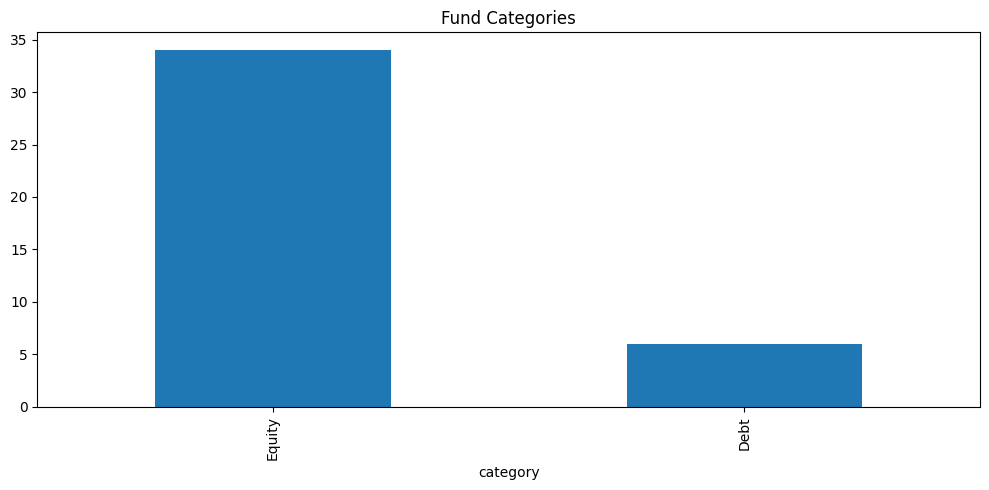

In [7]:
fund_master["category"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Fund Categories")
plt.tight_layout()
plt.savefig("../reports/charts/fund_categories.png")
plt.show()

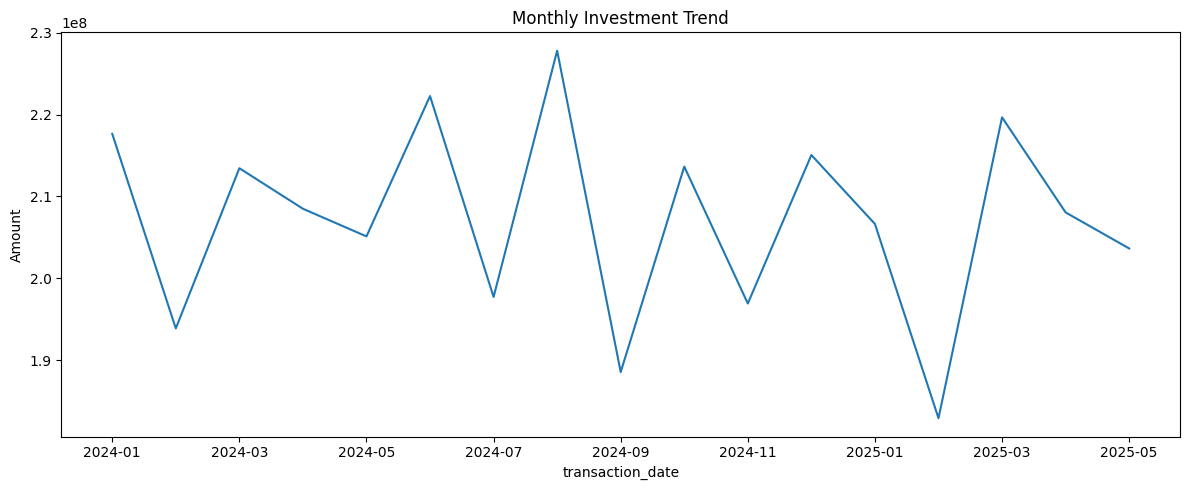

In [8]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

monthly = (
    transactions.groupby(
        transactions["transaction_date"].dt.to_period("M")
    )["amount_inr"]
    .sum()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12,5))
monthly.plot()

plt.title("Monthly Investment Trend")
plt.ylabel("Amount")

plt.tight_layout()

plt.savefig("../reports/charts/monthly_trend.png")
plt.show()

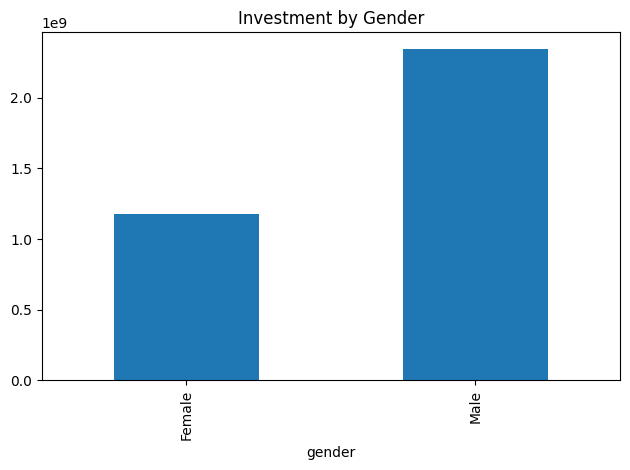

In [9]:
gender = (
    transactions.groupby("gender")["amount_inr"]
    .sum()
)

gender.plot(kind="bar")

plt.title("Investment by Gender")

plt.tight_layout()

plt.savefig("../reports/charts/gender_analysis.png")
plt.show()

# EDA Insights

- Top states contribute the majority of investment volume.
- SIP transactions dominate investor activity.
- Middle-aged investors form the largest investment segment.
- Equity categories are the most common mutual fund category.
- Monthly investment activity shows consistent participation.
- Investment contribution varies across genders.

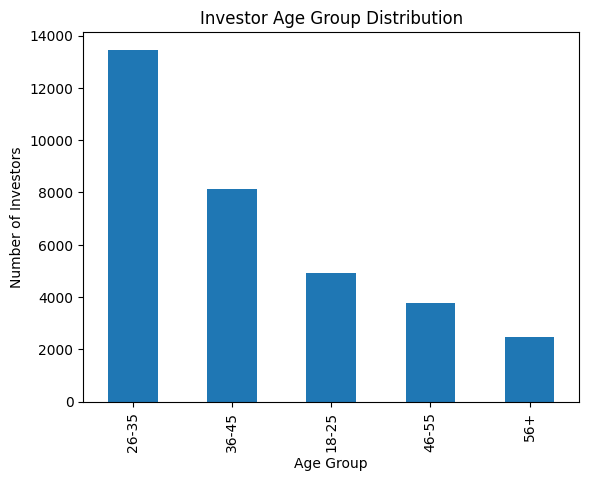

In [11]:
transactions["age_group"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.savefig(
    "../reports/charts/age_group_distribution.png"
)

plt.show()

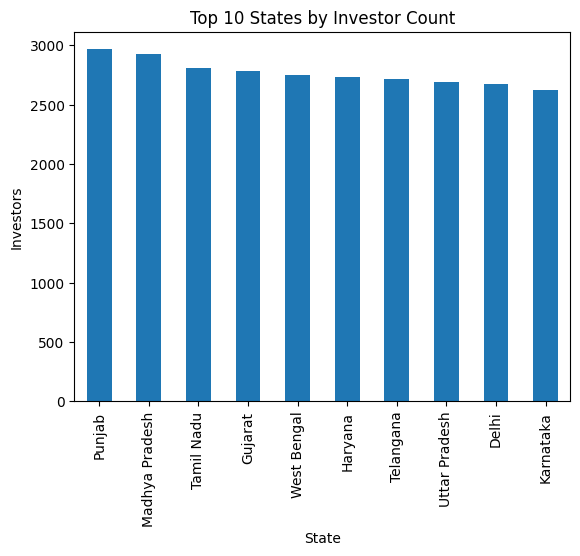

In [10]:
transactions["state"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 States by Investor Count")
plt.xlabel("State")
plt.ylabel("Investors")

plt.savefig(
    "../reports/charts/top_states_investors.png"
)

plt.show()

In [12]:
aum_by_house = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

aum_by_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


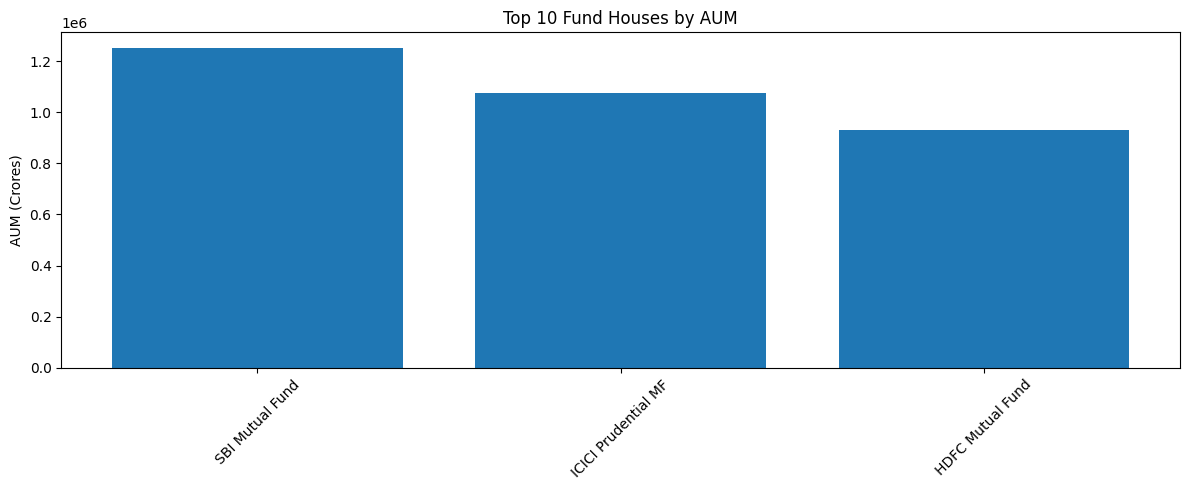

In [21]:
top10 = aum_by_house.sort_values(
    by="aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top10["fund_house"],
    top10["aum_crore"]
)

plt.xticks(rotation=45)
plt.title("Top 10 Fund Houses by AUM")
plt.ylabel("AUM (Crores)")

plt.tight_layout()

plt.savefig("../reports/charts/top10_fundhouse_aum.png")

plt.show()

In [14]:
category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


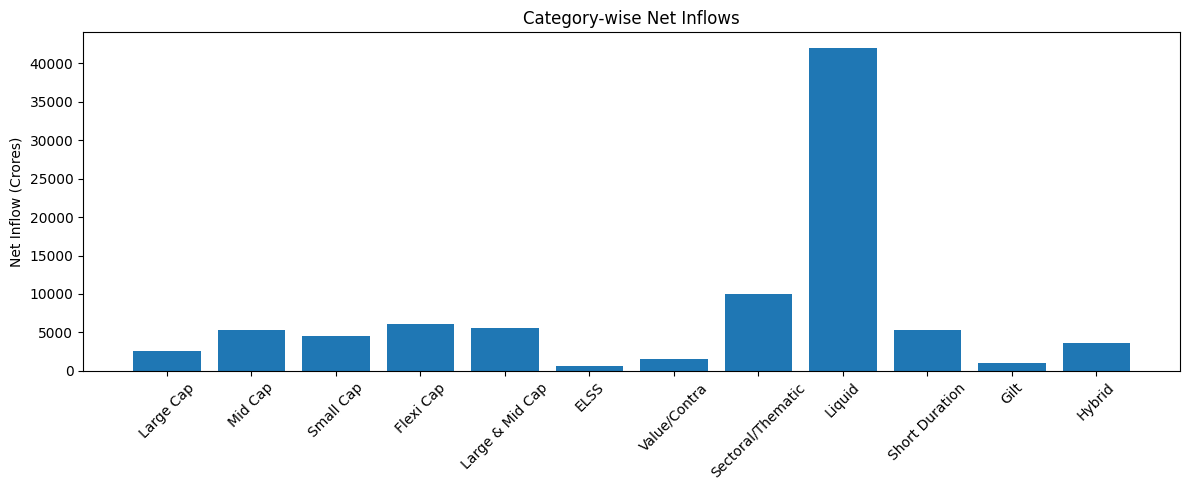

In [22]:
plt.figure(figsize=(12,5))

plt.bar(
    category["category"],
    category["net_inflow_crore"]
)

plt.xticks(rotation=45)

plt.title("Category-wise Net Inflows")
plt.ylabel("Net Inflow (Crores)")

plt.tight_layout()

plt.savefig("../reports/charts/category_inflows.png")

plt.show()

In [16]:
folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


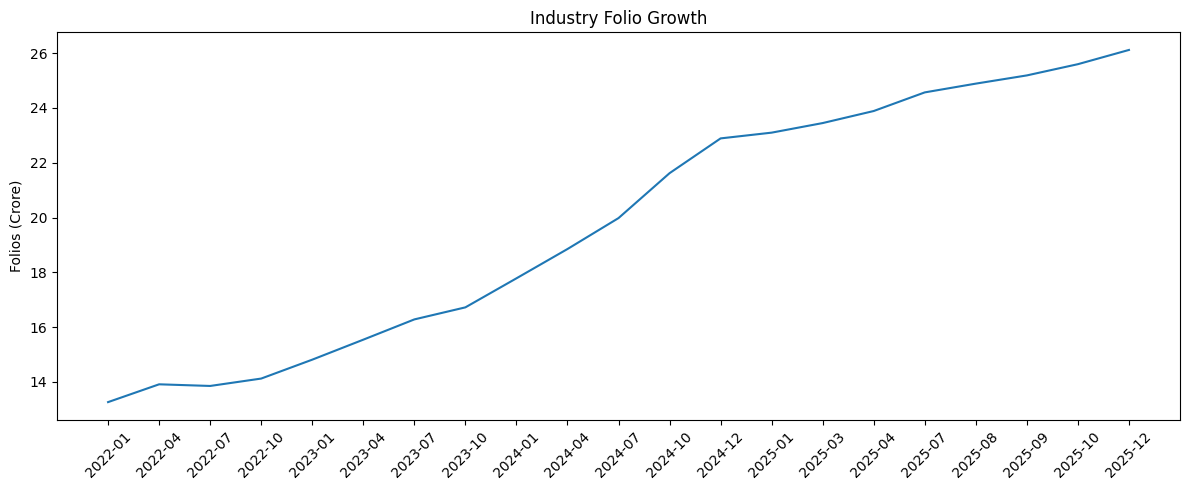

In [23]:
plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.xticks(rotation=45)

plt.title("Industry Folio Growth")
plt.ylabel("Folios (Crore)")

plt.tight_layout()

plt.savefig("../reports/charts/industry_folio_growth.png")

plt.show()

In [18]:
aum_by_house.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

In [19]:
category.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [20]:
folio.columns.tolist()

['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

# Key Insights

1. SIP transactions account for the majority of investor activity.
2. Investors aged 26–45 form the largest investment segment.
3. Metro cities contribute significantly to transaction volume.
4. Monthly SIP inflows show consistent growth.
5. AUM is concentrated among a few large fund houses.
6. Equity categories attract the highest inflows.
7. Retail participation continues to grow steadily.